# Working with Tabular Data in Python — *Arabidopsis* roots in space

Welcome! In this notebook you will learn to use [pandas](https://pandas.pydata.org/)
and [NumPy](https://numpy.org/) to work with real spaceflight biology data.

## The story: how do plant roots respond to spaceflight?

You have joined a space-biology team studying how the model plant
[*Arabidopsis thaliana*](https://en.wikipedia.org/wiki/Arabidopsis_thaliana)
adapts to the [International Space Station](https://www.nasa.gov/international-space-station/).
Your data come from the **CARA experiment** (*Characterizing Arabidopsis Root
Attractions*; Paul & Ferl) — NASA OSDR dataset
[**OSD-120 / GLDS-120**](https://osdr.nasa.gov/bio/repo/data/studies/OSD-120).
Seedling **roots** were grown on the ISS (**spaceflight, FLT**) and on the
ground (**ground control, GC**), then RNA-sequenced to measure how strongly every
gene is switched on.

By the end of this notebook you'll be comfortable:

* Loading data from files with pandas
* Selecting and filtering specific parts of your data
* Performing calculations on your data using NumPy
* Resolving NaNs and outliers
* Performing normalization and standardization

***Tip: to run this live, open it in Colab/Binder or `jupyter` and execute each
cell from top to bottom.***

----

## Loading Data with Pandas

Many scientific data tables are stored in the comma-separated-value format (CSV). These tables are easily read using the Python library `pandas`.

* Rows and Columns: Think of the file like a big table with rows and columns. Each row represents a single entry.

* Comma Separated: The values in each row are separated by commas.

* Headers (Optional): The first row can act like a header, giving names to each column.

Here's an example of a simple CSV file for a movie collection:

>`Title,Genre,Year`

>`The Shawshank Redemption,Drama,1994`

>`The Godfather,Crime,1972`

>`The Dark Knight,Action,2008`

In this example, each row represents a movie. The first row is the header with titles for each column ("Title", "Genre", "Year"). The commas separate the values in each row, like ",Drama,1994" for "The Shawshank Redemption".

CSV files are great because they're simple and almost any computer program can understand them. This makes it easy to share and work with data between different tools.  They're like a universal language for tables!

**Let's load a CSV file of RNA sequencing data from the [NASA Open Science Data Repository (OSDR)](https://osdr.nasa.gov/bio/).** This data was collected from the **roots of *Arabidopsis thaliana* seedlings** grown on the International Space Station as part of the [CARA experiment](https://osdr.nasa.gov/bio/repo/data/studies/OSD-120) (*Characterizing Arabidopsis Root Attractions*; Paul & Ferl). The experiment grew plants in spaceflight (FLT) and on the ground (GC) to assess the effects of microgravity on how plant roots grow and which genes they switch on.

We will use the OSDR API to access the file programmatically. More information on the OSDR API can be found [here](https://genelab.nasa.gov/genelabAPIs).

In [1]:
import pandas as pd

# Read the CARA (OSD-120) Arabidopsis root RNA-seq normalized counts into a DataFrame
url = ("https://osdr.nasa.gov/geode-py/ws/studies/OSD-120/download"
       "?source=datamanager&file=GLDS-120_rna_seq_Normalized_Counts_GLbulkRNAseq.csv")
df = pd.read_csv(url, index_col=0)

# Print the first 5 rows of the DataFrame
df.head()

,Atha_Col-0_root_GC_Alight_Rep1_GSM2493759_Day13,Atha_Col-0_root_GC_Alight_Rep2_GSM2493760_Day13,Atha_Ws_root_GC_Alight_Rep1_GSM2493762_Day13,Atha_Ws_root_GC_Alight_Rep2_GSM2493763_Day13,Atha_Ws_root_GC_Alight_Rep3_GSM2493764_Day13,Atha_Col-0-PhyD_root_GC_Alight_Rep1_GSM2493765_Day13,Atha_Col-0-PhyD_root_GC_Alight_Rep2_GSM2493766_Day13,Atha_Col-0-PhyD_root_GC_Alight_Rep3_GSM2493767_Day13,Atha_Col-0_root_GC_dark_Rep1_GSM2493768_Day13,Atha_Col-0_root_GC_dark_Rep2_GSM2493769_Day13,...,Atha_Col-0_root_FLT_dark_Rep1_GSM2493786_Day13,Atha_Col-0_root_FLT_dark_Rep2_GSM2493787_Day13,Atha_Col-0_root_FLT_dark_Rep3_GSM2493788_Day13,Atha_Ws_root_FLT_dark_Rep1_GSM2493789_Day13,Atha_Ws_root_FLT_dark_Rep2_GSM2493790_Day13,Atha_Ws_root_FLT_dark_Rep3_GSM2493791_Day13,Atha_Col-0-PhyD_root_FLT_dark_Rep1_GSM2493792_Day13,Atha_Col-0-PhyD_root_FLT_dark_Rep2_GSM2493793_Day13,Atha_Col-0-PhyD_root_FLT_dark_Rep3_GSM2493794_Day13,Atha_Col-0_root_GC_Alight_Rep3_GSM2493761_Day13
AT1G01010,114.904131,138.527368,120.022494,264.937105,191.422936,242.517040,412.253673,210.840135,144.668736,201.744019,...,424.847210,147.983322,277.194348,115.874562,309.806447,320.963807,398.109857,104.633344,85.672000,105.632330
AT1G01020,673.515535,621.793455,645.936090,439.201986,522.399305,748.214534,537.977432,739.297948,656.648675,627.933477,...,463.448392,713.731341,961.798409,496.336366,569.696041,454.003757,581.384441,749.912117,688.502249,559.374814
AT1G01030,94.043792,94.223868,65.271628,103.706224,86.287958,103.357911,189.930809,141.967726,81.612611,110.981125,...,49.957938,80.945443,161.394188,43.761590,105.958171,136.696201,96.310749,182.954416,249.215970,123.892672
AT1G01040,164.879084,94.035143,238.621873,132.559195,182.120176,175.679477,205.565473,131.052912,171.811433,134.112724,...,83.333634,156.572361,101.033035,234.971130,209.744502,350.823340,155.615105,161.055119,189.724432,108.131266
AT1G01046,0.000000,0.000000,0.000000,0.000000,5.052491,0.000000,2.427154,0.000000,0.829751,0.000000,...,1.393093,0.000000,0.000000,0.000000,0.000000,0.000000,0.988599,0.000000,0.000000,1.004718


The code above imports `pandas` and uses `read_csv` to load the CARA RNA-seq table
into a pandas DataFrame, then shows the first 5 rows with `head()`.

In this table, **each column is one *Arabidopsis* root sample** and **each row is a
gene**, identified by its [AGI locus code](https://www.arabidopsis.org/) (e.g.
`AT1G01010`). Each value is the *normalized expression level* of that gene in that
sample. Read the column names closely — they encode the whole experiment:
`Atha` (species) · ecotype (`Col-0`, `Ws`, `Col-0-PhyD`) · `root` · **`GC`
(ground control) or `FLT` (spaceflight)** · `Alight`/`dark` · replicate.

**CHALLENGE QUESTION:** Read the column names. How many samples were grown in
**spaceflight (`FLT`)** and how many on the **ground (`GC`)**? *(Hint: count the
columns containing `FLT` versus `GC`.)*

**Double click here to enter your answer below.**

Answer:


---

## Exploring a DataFrame

Below, we will use a few basic methods to explore the data.

First, the `info()` function generates a summary of a pandas DataFrame. This summary includes various informative aspects of the data stored in the DataFrame.

* Non-null count: This shows the number of non-null (not missing) values in each column.
* Data types of each column: It lists the data type of each column in the DataFrame (e.g., integer, float, object). In our data, float64 represents the following:  
  * float: The column stores decimal numbers.
  * 64: The number of bits used to store each value in the column. In this case, 64 bits provide a high degree of precision for decimal numbers.

In [2]:
# Get information about the DataFrame
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 24740 entries, AT1G01010 to ATMG09730
Data columns (total 36 columns):
 #   Column                                                 Non-Null Count  Dtype  
---  ------                                                 --------------  -----  
 0   Atha_Col-0_root_GC_Alight_Rep1_GSM2493759_Day13        24740 non-null  float64
 1   Atha_Col-0_root_GC_Alight_Rep2_GSM2493760_Day13        24740 non-null  float64
 2   Atha_Ws_root_GC_Alight_Rep1_GSM2493762_Day13           24740 non-null  float64
 3   Atha_Ws_root_GC_Alight_Rep2_GSM2493763_Day13           24740 non-null  float64
 4   Atha_Ws_root_GC_Alight_Rep3_GSM2493764_Day13           24740 non-null  float64
 5   Atha_Col-0-PhyD_root_GC_Alight_Rep1_GSM2493765_Day13   24740 non-null  float64
 6   Atha_Col-0-PhyD_root_GC_Alight_Rep2_GSM2493766_Day13   24740 non-null  float64
 7   Atha_Col-0-PhyD_root_GC_Alight_Rep3_GSM2493767_Day13   24740 non-null  float64
 8   Atha_Col-0_root_GC_dark_Rep1_GSM2493768

**CHALLENGE QUESTION:** How many genes total are measured for each sample? (Hint: look at the "Non-Null Count" column.)

**Double click here to enter your answer below.**

Answer:

----

Next, the `df.describe()` provides a summary table of the central tendency (mean and median) and spread (standard deviation) of the numerical data in your DataFrame. This can be helpful for understanding the distribution of your data and identifying potential outliers.

* Count: This shows the number of non-null (not missing) values in each column.
* Mean: This represents the average value of the numerical data in the column.
* Std (standard deviation): This indicates how spread out the data is from the mean value in the column. A higher standard deviation suggests more variation in the data.
*Min (minimum): This shows the smallest value present in the column.
*25% (first quartile): This represents the value where 25% of the data falls below it and 75% falls above it in the column (essentially the median of the lower half of the data).
* 50% (median): This is the middle value of the data when the column is sorted numerically. It represents the value that separates the lower and upper halves of the data.
*75% (third quartile): This represents the value where 75% of the data falls below it and 25% falls above it in the column (essentially the median of the upper half of the data).
*Max (maximum): This shows the largest value present in the column.



In [3]:
# Show some summary statistics of the numerical columns
df.describe()

,Atha_Col-0_root_GC_Alight_Rep1_GSM2493759_Day13,Atha_Col-0_root_GC_Alight_Rep2_GSM2493760_Day13,Atha_Ws_root_GC_Alight_Rep1_GSM2493762_Day13,Atha_Ws_root_GC_Alight_Rep2_GSM2493763_Day13,Atha_Ws_root_GC_Alight_Rep3_GSM2493764_Day13,Atha_Col-0-PhyD_root_GC_Alight_Rep1_GSM2493765_Day13,Atha_Col-0-PhyD_root_GC_Alight_Rep2_GSM2493766_Day13,Atha_Col-0-PhyD_root_GC_Alight_Rep3_GSM2493767_Day13,Atha_Col-0_root_GC_dark_Rep1_GSM2493768_Day13,Atha_Col-0_root_GC_dark_Rep2_GSM2493769_Day13,...,Atha_Col-0_root_FLT_dark_Rep1_GSM2493786_Day13,Atha_Col-0_root_FLT_dark_Rep2_GSM2493787_Day13,Atha_Col-0_root_FLT_dark_Rep3_GSM2493788_Day13,Atha_Ws_root_FLT_dark_Rep1_GSM2493789_Day13,Atha_Ws_root_FLT_dark_Rep2_GSM2493790_Day13,Atha_Ws_root_FLT_dark_Rep3_GSM2493791_Day13,Atha_Col-0-PhyD_root_FLT_dark_Rep1_GSM2493792_Day13,Atha_Col-0-PhyD_root_FLT_dark_Rep2_GSM2493793_Day13,Atha_Col-0-PhyD_root_FLT_dark_Rep3_GSM2493794_Day13,Atha_Col-0_root_GC_Alight_Rep3_GSM2493761_Day13
count,24740.000000,24740.000000,24740.000000,24740.000000,24740.000000,24740.000000,24740.000000,24740.000000,24740.000000,24740.000000,...,24740.000000,24740.000000,24740.000000,24740.000000,24740.000000,24740.000000,24740.000000,24740.000000,24740.000000,24740.000000
mean,559.337844,593.633376,539.743709,597.703942,547.192803,543.343282,631.683531,587.622265,544.260695,559.047724,...,554.044853,557.886509,627.591738,572.177923,597.289346,578.673069,602.713523,581.926073,543.592029,621.856870
std,3153.531682,2675.762813,3662.655942,2845.543715,2912.096926,3065.270394,4020.867413,3577.861442,2989.692935,4535.113855,...,2412.452829,3052.547830,3318.598346,2964.335061,3562.933207,4362.202559,3346.134178,3885.361060,3780.244281,3009.819386
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,9.742612,14.057900,6.485496,12.950401,10.115325,11.474406,14.945511,13.067790,9.691105,7.254628,...,11.339764,8.467588,13.851376,7.781211,10.165527,11.282189,13.805685,8.037476,4.849847,14.592185
50%,131.321465,128.244008,118.999388,136.478462,133.005962,134.754520,141.803238,140.385344,129.258407,124.705485,...,133.633570,121.082047,133.658136,119.045119,128.501821,129.806600,139.163498,127.773863,122.290952,133.249594
75%,426.362942,412.978470,408.909881,426.408048,427.133567,420.159057,459.713247,436.835356,418.959420,408.535272,...,434.934470,404.790200,440.709921,402.536912,415.478778,424.048682,447.498495,428.951127,434.214599,428.374115
max,291046.406369,195304.574041,389326.874873,204179.589790,283041.445768,292594.183978,378971.341680,353753.023588,274183.608950,517939.073204,...,189109.704352,263088.777039,271042.243131,251068.664062,336939.398309,457229.040344,301381.852071,468954.042107,387957.287935,254906.821849


Next, we select specific columns to examine them more closely. Below we use square-
bracket notation to pull out one **ground-control** root sample and one
**spaceflight** root sample so we can compare them side by side.

In [4]:
# Select one ground-control and one spaceflight root sample
ground = "Atha_Col-0_root_GC_Alight_Rep1_GSM2493759_Day13"
flight = "Atha_Col-0_root_FLT_Alight_Rep1_GSM2493777_Day13"
selected_columns = df[[ground, flight]]
selected_columns

,Atha_Col-0_root_GC_Alight_Rep1_GSM2493759_Day13,Atha_Col-0_root_FLT_Alight_Rep1_GSM2493777_Day13
AT1G01010,114.904131,247.595554
AT1G01020,673.515535,582.008955
AT1G01030,94.043792,64.786704
AT1G01040,164.879084,86.649525
AT1G01046,0.000000,0.000000
...,...,...
ATMG01390,9743.310885,7052.750350
ATMG01400,0.000000,3.394086
ATMG01410,0.905213,4.221993
ATMG09450,0.000000,1.634395


Finally, we can filter rows by a condition. The code below keeps only the genes
that are **highly expressed in the spaceflight root sample** (normalized
expression greater than 1000) — a quick way to focus on the most active genes.

In [5]:
# Keep only genes strongly expressed in the spaceflight sample
filtered_df = df[df[flight] > 1000]
filtered_df

,Atha_Col-0_root_GC_Alight_Rep1_GSM2493759_Day13,Atha_Col-0_root_GC_Alight_Rep2_GSM2493760_Day13,Atha_Ws_root_GC_Alight_Rep1_GSM2493762_Day13,Atha_Ws_root_GC_Alight_Rep2_GSM2493763_Day13,Atha_Ws_root_GC_Alight_Rep3_GSM2493764_Day13,Atha_Col-0-PhyD_root_GC_Alight_Rep1_GSM2493765_Day13,Atha_Col-0-PhyD_root_GC_Alight_Rep2_GSM2493766_Day13,Atha_Col-0-PhyD_root_GC_Alight_Rep3_GSM2493767_Day13,Atha_Col-0_root_GC_dark_Rep1_GSM2493768_Day13,Atha_Col-0_root_GC_dark_Rep2_GSM2493769_Day13,...,Atha_Col-0_root_FLT_dark_Rep1_GSM2493786_Day13,Atha_Col-0_root_FLT_dark_Rep2_GSM2493787_Day13,Atha_Col-0_root_FLT_dark_Rep3_GSM2493788_Day13,Atha_Ws_root_FLT_dark_Rep1_GSM2493789_Day13,Atha_Ws_root_FLT_dark_Rep2_GSM2493790_Day13,Atha_Ws_root_FLT_dark_Rep3_GSM2493791_Day13,Atha_Col-0-PhyD_root_FLT_dark_Rep1_GSM2493792_Day13,Atha_Col-0-PhyD_root_FLT_dark_Rep2_GSM2493793_Day13,Atha_Col-0-PhyD_root_FLT_dark_Rep3_GSM2493794_Day13,Atha_Col-0_root_GC_Alight_Rep3_GSM2493761_Day13
AT1G01050,2884.404670,3557.528554,2338.754405,2618.644881,2890.736840,2431.910716,3818.282914,2983.930406,2765.071443,2399.890435,...,2540.467405,3009.298217,3135.674847,2786.565300,2443.498562,1919.472265,2787.082512,2037.008485,3123.651897,3726.874504
AT1G01090,2221.125127,1553.755167,2194.661434,1273.064072,1723.167661,2377.236668,1337.742208,1652.094795,2882.042298,2239.442866,...,2054.469276,2955.505409,1836.654195,2539.143385,1583.112899,1726.262399,1758.169079,2077.242896,1938.761591,2551.480567
AT1G01100,10152.937694,15205.879180,12915.091347,13703.332917,10143.736720,12275.849697,7938.603648,10323.955104,11644.548452,14700.403322,...,8440.377919,11370.671719,11122.857676,13546.734405,12700.438947,11977.646127,11216.197474,17082.433450,11309.335076,13444.946645
AT1G01300,1028.539606,550.898122,886.262384,651.529834,638.815328,1323.863617,607.866233,743.692482,1134.186043,1050.259707,...,1078.058905,1107.106765,1172.631283,1381.139247,902.646656,1207.003022,946.681709,806.067423,1158.213540,1031.977682
AT1G01510,1413.096245,512.936201,1357.163239,893.796279,1012.525119,942.451716,592.984191,1032.908494,1239.453743,1225.828595,...,1091.542347,1220.692569,540.362102,1190.725275,1229.787447,1108.305015,1111.232804,822.603517,1558.499436,720.724506
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ATMG00030,28894.231081,16422.888129,30981.889870,13486.233709,15015.300679,25351.316070,29866.593791,24864.679093,14814.566857,33674.258417,...,4147.708021,16254.375023,26582.989377,14121.758959,21260.890158,42544.993744,16902.404929,38330.652161,46861.500140,15974.379548
ATMG00090,2330.169092,1408.268419,2596.990975,1151.366249,2183.599989,2031.908266,1805.932663,1964.471599,2093.307720,4816.736242,...,1763.062748,2793.532478,1633.170372,3262.508991,2604.583366,4057.710404,2589.342442,3357.232851,3814.178940,1190.409905
ATMG00580,1901.481729,1759.534891,2702.243724,1602.298496,2797.597988,3000.683188,2445.894411,2212.734699,2069.746907,3571.229633,...,1721.547309,2891.205426,2018.760155,2402.601491,2367.511866,3126.326512,2287.898041,3345.737533,4775.400350,1502.025247
ATMG01190,1313.280851,592.811475,1621.339721,783.749068,1267.573269,1364.202225,1028.689842,826.198497,798.735358,1479.639145,...,1230.311036,1006.328253,508.246987,1256.756242,975.432480,1613.877798,1601.456717,1322.264180,2062.503873,573.241475


**CHALLENGE QUESTION:** How many genes are left in the filtered DataFrame? (Hint: look at the dimensions reported below the table.)

**Double click here to enter your answer below.**

Answer:

---

## Numerical Operations in NumPy

Now, we will use the NumPy library to demonstrate a few useful numerical operations that can be performed on a DataFrame.

First, we can caltulate the mean (average) expression level for each gene across all samples. In the code below, we use the NumPy function `.mean()` to calculate the mean of each gene (`axis=1` refers to rows).

In [6]:
import numpy as np

# Calculate mean expression for each gene (print the first 10 genes)
mean_expression = np.mean(df, axis=1)
"Mean Expression:", mean_expression[0:10]

('Mean Expression:',
 AT1G01010     230.562159
 AT1G01020     605.925457
 AT1G01030     100.417884
 AT1G01040     174.356616
 AT1G01046       0.646205
 AT1G01050    2811.835601
 AT1G01060     201.036841
 AT1G01070     469.780135
 AT1G01080      70.751578
 AT1G01090    2049.506341
 dtype: float64)

**CHALLENGE QUESTION:** Which gene has the highest mean expression across all samples? Which gene has the lowest?

**Double click here to enter your answer below.**

Answer:

----
Similarly, we can use the NumPy function `.std()` to calculate the [standard deviation](https://en.wikipedia.org/wiki/Standard_deviation) of each gene.

In [7]:
# Calculate standard deviation for each gene
std_dev = np.std(df, axis=1)
"Standard Deviation:", std_dev[0:10]

('Standard Deviation:',
 AT1G01010    102.375701
 AT1G01020    105.582709
 AT1G01030     44.460344
 AT1G01040     66.752965
 AT1G01046      1.093698
 AT1G01050    469.338444
 AT1G01060    220.288986
 AT1G01070    245.846576
 AT1G01080     25.193479
 AT1G01090    474.060348
 dtype: float64)

Next, we can identify which genes have the highest average expression across all samples. This is a useful way of identifying unusual trends in a dataset.

The code below finds the top 3 most highly expressed genes based on their average expression across samples.
* `df.mean(axis=1)` calculates the average expression level for each sample *(`axis=1` refers to rows).
* `.sort_values(ascending=False)` sorts the genes by their average expression in descending order (highest first).
* `.head(3).index.tolist()` selects the top 3 entries and converts the index (gene names) to a list.

In [8]:
# Find top 3 most highly expressed genes (average expression)
top_genes = df.mean(axis=1).sort_values(ascending=False).head(3).index.tolist()
print("Top 3 Expressed Genes:", top_genes)

Top 3 Expressed Genes: ['AT3G41768', 'ATMG00020', 'AT1G07590']


## Missing Value Handling (NaNs)

Real measurements are often incomplete. Below is a small table of root traits from
a handful of **CARA *Arabidopsis* seedlings** — root length, root surface area, and
the number of lateral roots — where a couple of values are **missing** (NaN, "not a
number"), as happens when a sample is damaged or a measurement is skipped. We'll use
it to demonstrate a few data-preparation techniques.

In [9]:
# A few CARA Arabidopsis seedlings, with some missing measurements
data = {'root_length_cm':     [3.0, 3.6, 2.8, 4.1, 3.4, np.nan],
        'surface_area_mm2':   [4.5, 6.0, 4.0, 7.2, 5.1, 18.5],
        'lateral_root_count': [2, 5, 1, 8, 4, None]}
df = pd.DataFrame(data)
df

,root_length_cm,surface_area_mm2,lateral_root_count
0,3.0,4.5,2.0
1,3.6,6.0,5.0
2,2.8,4.0,1.0
3,4.1,7.2,8.0
4,3.4,5.1,4.0
5,NaN,18.5,NaN


We will now check how many missing values (NaNs) exist in each column of the DataFrame, using the `.isnull()` function:

In [10]:
# Check for missing values (NaNs)
print(df.isnull().sum())  # Check how many missing values in each column

root_length_cm        1
surface_area_mm2      0
lateral_root_count    1
dtype: int64


If your data has missing values (NaNs), that can be a problem for downstream analysis such as machine learning. Two common approaches for dealing with missing values are to fill them with specific values such as the mean or median of the other values, or to drop rows or columns that contain missing values.

**Option 1: Filling with specific values (e.g., mean or median):**

In the code below, we fill the missing value in the `root_length_cm` column with the mean of the other root lengths. We then fill the missing value in the `lateral_root_count` column with the median of the other counts (a median keeps the value a sensible whole-ish number). We print out the new DataFrame to ensure that there are no NaNs left.

In [11]:
# Fill the missing root length with the mean root length
df['root_length_cm'].fillna(df['root_length_cm'].mean(), inplace=True)

# Fill the missing lateral-root count with the median count
df['lateral_root_count'].fillna(df['lateral_root_count'].median(), inplace=True)

df

C:\Users\drric\AppData\Local\Temp\ipykernel_12076\89100529.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['root_length_cm'].fillna(df['root_length_cm'].mean(), inplace=True)
C:\Users\drric\AppData\Local\Temp\ipykernel_12076\89100529.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves a

,root_length_cm,surface_area_mm2,lateral_root_count
0,3.00,4.5,2.0
1,3.60,6.0,5.0
2,2.80,4.0,1.0
3,4.10,7.2,8.0
4,3.40,5.1,4.0
5,3.38,18.5,4.0


**Option 2: Dropping rows with missing values (not recommended if many missing values):**

In the second option, we drop rows that contain missing values using the `dropna()` function. However, if there are many missing values in your DataFrame, this is not recommended because you will be losing a lot of data.

In [12]:
data = {'root_length_cm':     [3.0, 3.6, 2.8, 4.1, 3.4, np.nan],
        'surface_area_mm2':   [4.5, 6.0, 4.0, 7.2, 5.1, 18.5],
        'lateral_root_count': [2, 5, 1, 8, 4, None]}
df = pd.DataFrame(data)

df.dropna(inplace=True)
df

,root_length_cm,surface_area_mm2,lateral_root_count
0,3.0,4.5,2.0
1,3.6,6.0,5.0
2,2.8,4.0,1.0
3,4.1,7.2,8.0
4,3.4,5.1,4.0


## 4. Identifying Outliers

**Outliers** are data points that fall significantly outside the main distribution of the data. They can be very high or very low values compared to the majority of the data points in a column.

Outliers can significantly influence calculations like mean, median, and standard deviation. This can distort our understanding of the data. Machine learning algorithms often rely on assumptions about the underlying data distribution. Outliers can violate these assumptions and lead to inaccurate models.

A **boxplot** is a way to visualize how data is spread out.
* It has a box in the middle with a line in the center representing the median (the middle value when the data is ordered).
* The box shows the interquartile range (IQR), which represents the middle half of the data.
* There are lines extending from the box called whiskers. These whiskers typically extend to 1.5 times the IQR above and below the box.
* **Points outside the whiskers are considered potential outliers.**

The code below uses `matplotlib.pyplot` to create a boxplot and visualize potential outliers in the `surface_area_mm2` column — notice one seedling has an unusually large root surface area:

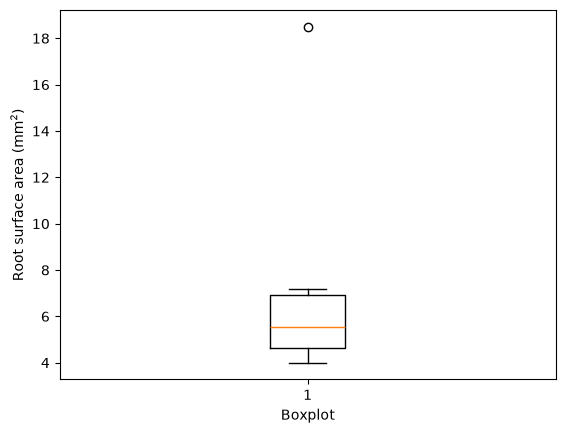

In [13]:
import matplotlib.pyplot as plt

# A few CARA Arabidopsis seedlings (one has an unusually large root surface area)
data = {'root_length_cm':     [3.0, 3.6, 2.8, 4.1, 3.4, np.nan],
        'surface_area_mm2':   [4.5, 6.0, 4.0, 7.2, 5.1, 18.5],
        'lateral_root_count': [2, 5, 1, 8, 4, None]}
df = pd.DataFrame(data)

# Create a boxplot of root surface area
plt.boxplot(df['surface_area_mm2'])

# Label the axes
plt.xlabel("Boxplot")
plt.ylabel("Root surface area (mm$^2$)")

# Show the plot
plt.show()

**CHALLENGE QUESTION:** How many outliers are there in the `surface_area_mm2` column? Is it an unusually high or unusually low value?

**Double click here to enter your answer below.**

Answer:

---

## 5. Removing Outliers (cautiously!)

In some cases, it is appropriate to remove outliers from a dataset prior to downstream analysis such as machine learning. However, it is important to consider domain knowledge before removing data points in case they are important, and to transparently document the process of removing data points.

In the code below, we calculate the lower and upper bounds for outliers based on 1.5 times the IQR from the quartiles. We then filter the DataFrame to keep only rows where `surface_area_mm2` falls within the calculated bounds.

In [14]:
# Option 1: Remove outliers (be cautious, consider domain knowledge)
# IQR (Interquartile Range) based outlier detection
Q1 = df['surface_area_mm2'].quantile(0.25)
Q3 = df['surface_area_mm2'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - (1.5 * IQR)
upper_bound = Q3 + (1.5 * IQR)
df = df[(df['surface_area_mm2'] >= lower_bound) & (df['surface_area_mm2'] <= upper_bound)]
df

,root_length_cm,surface_area_mm2,lateral_root_count
0,3.0,4.5,2.0
1,3.6,6.0,5.0
2,2.8,4.0,1.0
3,4.1,7.2,8.0
4,3.4,5.1,4.0


## Normalization (0-1 scale)

Machine learning algorithms often work better when features are on a similar scale. **Normalization** and **standardization** can improve the performance of the model.

Normalizing data between 0 and 1 for machine learning algorithms can be beneficial for several reasons:

* Equal Footing: Features on different scales are put on a common ground, preventing features with larger values from dominating the learning process.
* Improved Convergence: Normalization can help some algorithms converge faster during the training process, leading to potentially better models.
* Distance-based Algorithms: Normalization is particularly important for algorithms that rely on distance metrics (like k-Nearest Neighbors) to function effectively.

In the code below, we normalize the features in the DataFrame to a range between 0 and 1:

In [15]:
# Normalization (scale to range 0-1)
df_norm = (df - df.min()) / (df.max() - df.min())
df_norm

,root_length_cm,surface_area_mm2,lateral_root_count
0,0.153846,0.15625,0.142857
1,0.615385,0.62500,0.571429
2,0.000000,0.00000,0.000000
3,1.000000,1.00000,1.000000
4,0.461538,0.34375,0.428571


## Standardization (mean 0, std 1)

Standardizing data to have a mean of 0 and standard deviation of 1 is useful in machine learning because it:

* Levels the Playing Field: Features are centered around the same mean, preventing features with larger scales from disproportionately influencing the model.
* Improves Interpretation: Standardized coefficients in the model become easier to interpret since they represent the relative impact of each feature in units of standard deviation.


In the code below, we standardize the DataFrame using `sklearn.preprocessing.StandardScaler()`.

In [16]:
# Standardization (scale to mean 0 and standard deviation 1)
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df_scaled = scaler.fit_transform(df)
print(df_scaled)

[[-0.83001885 -0.75707041 -0.81649658]
 [ 0.48053723  0.56340124  0.40824829]
 [-1.26687088 -1.19722763 -1.22474487]
 [ 1.5726673   1.61977856  1.63299316]
 [ 0.0436852  -0.22888175  0.        ]]
